Laboratorium 5 Kaja Thiel 21310


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional, Input
from keras.optimizers import SGD, Adam
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from keras.losses import Huber

In [ ]:
def plot_predictions(test, predicted):
    plt.plot(test, color='red', label='Real IBM Stock Price')
    plt.plot(predicted, color='blue', label='Predicted IBM Stock Price')
    plt.title('IBM Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('IBM Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test, predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("-" * 30)
    print("Błąd średniokwadratowy modelu: {:.2f}".format(rmse))
    print("-" * 30)

def return_mae(test, predicted):
    mae = mean_absolute_error(test, predicted)
    mape = mean_absolute_percentage_error(test, predicted) * 100
    print("Średni błąd bezwzględny: {:.2f}".format(mae))
    print("Średni błąd bezwzględny procentowy: {:.2f}%".format(mape))
    print("-" * 30)

In [5]:
dataset = pd.read_csv('sample_data/IBM_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=['Date'])
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


In [6]:
training_set = dataset[:'2016'].iloc[:,1:2].values
test_set = dataset['2017':].iloc[:,1:2].values

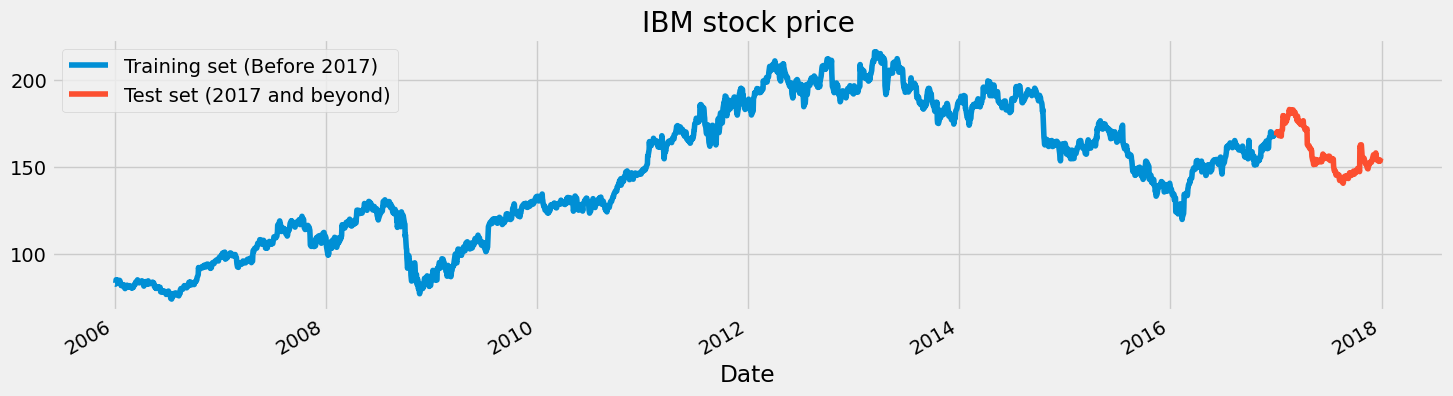

In [7]:
dataset["High"][:'2016'].plot(figsize=(16,4), legend=True)
dataset["High"]['2017':].plot(figsize=(16,4), legend=True)
plt.legend(['Training set (Before 2017)', 'Test set (2017 and beyond)'])
plt.title('IBM stock price')
plt.show()

In [8]:
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

In [9]:
X_train = []
y_train = []
for i in range(60,2769):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)

In [10]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [11]:
regressor = Sequential()
regressor.add(Input(shape=(X_train.shape[1], 1)))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop', loss='mean_squared_error')

regressor.fit(X_train, y_train, epochs=50, batch_size=32)

Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - loss: 0.0217
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 0.0104
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0083
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - loss: 0.0069
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - loss: 0.0061
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - loss: 0.0063
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 0.0051
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 0.0045
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - loss: 0.0047
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.0042
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 0.0041
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - loss: 0.0036
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - loss: 0.0038
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 0.0033
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 0.0033

In [12]:
dataset_total = pd.concat((dataset["High"][:'2016'], dataset["High"]['2017':]), axis=0)
inputs = dataset_total[len(dataset_total)-len(test_set) - 60:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)

In [13]:
X_test = []
for i in range(60,311):
    X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step


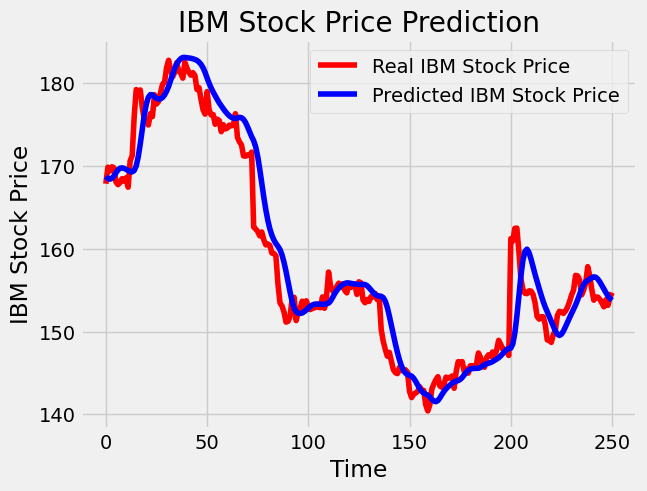

In [14]:
plot_predictions(test_set, predicted_stock_price)

In [15]:
return_rmse(test_set, predicted_stock_price)
return_mae(test_set, predicted_stock_price)

------------------------------
Błąd średniokwadratowy modelu: 3.17
------------------------------
Średni błąd bezwzględny: 2.21
Średni błąd bezwzględny procentowy: 1.39%
------------------------------


In [16]:
regressorGRU = Sequential()
regressorGRU.add(Input(shape=(X_train.shape[1], 1)))
regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(GRU(units=50, activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(Dense(units=1))

regressorGRU.compile(optimizer='rmsprop', loss='mean_squared_error')
early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
regressorGRU.fit(X_train, y_train, epochs=100, batch_size=32, callbacks=[early_stop])

Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - loss: 0.0192
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0087
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - loss: 0.0070
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0070
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0053
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - loss: 0.0049
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0045
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - loss: 0.0044
Epoch 9/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0039
Epoch 10/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0038
Epoch 11/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - loss: 0.0033
Epoch 12/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0035
Epoch 13/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.0032
Epoch 14/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0033
Epoch 15/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - 

In [17]:
X_test = []
for i in range(60,311):
    X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
GRU_predicted_stock_price = regressorGRU.predict(X_test)
GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step


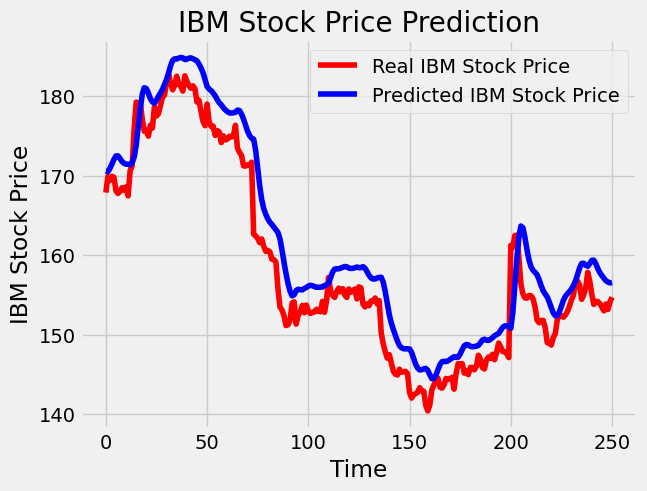

In [18]:
plot_predictions(test_set, GRU_predicted_stock_price)

In [19]:
return_rmse(test_set, GRU_predicted_stock_price)
return_mae(test_set, GRU_predicted_stock_price)

------------------------------
Błąd średniokwadratowy modelu: 4.00
------------------------------
Średni błąd bezwzględny: 3.54
Średni błąd bezwzględny procentowy: 2.25%
------------------------------


Porównanie bazowych architektur: LSTM vs GRU

Dokładność predykcji: W testowanej konfiguracji bazowej (optymalizator RMSprop, funkcja straty MSE), model LSTM poradził sobie zauważalnie lepiej. Osiągnął niższy błąd średniokwadratowy (RMSE: 3.17) oraz średni błąd bezwzględny procentowy (MAPE: 1.39%). Dla porównania model GRU wygenerował wyższe błędy (RMSE: 4.00, MAPE: 2.25%).

Prędkość uczenia: Czas trenowania pojedynczej epoki był zbliżony dla obu architektur i wynosił średnio od 5 do 11 sekund na krok. Model GRU, dzięki zaimplementowaniu mechanizmu Early Stopping (monitorującego loss), zakończył proces uczenia szybciej (na 56. z 100 zaplanowanych epok). Mimo dłuższego potencjalnego czasu nauki, szybkie zatrzymanie zapobiegło przeuczeniu, ale nie pozwoliło mu przebić dokładności sztywno trenowanego modelu LSTM (50 epok).